In [1]:
import tensorflow as tf # type: ignore
import matplotlib.pyplot as plt 
from PIL import Image 
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

from oos_data_loader import *
BATCH_SIZE = 4

2024-11-14 15:36:24.458231: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-14 15:36:24.466850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-14 15:36:24.476201: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-14 15:36:24.479385: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-14 15:36:24.486946: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def reverse_preprocess_input(img):
    """
    Reverse the preprocessing applied by keras.applications.resnet50.preprocess_input.
    
    Args:
    img: Preprocessed image (with 3 channels, values subtracted by ImageNet mean).
    
    Returns:
    Reversed image in the range [0, 255].
    """
    # If the input is a TensorFlow tensor, convert it to a NumPy array
    if isinstance(img, tf.Tensor):
        img = img.numpy()

    img = img.astype(np.float64)
    
    # Reverse the mean subtraction
    img[..., 0] += 103.939  # Add back the ImageNet mean for the R channel
    img[..., 1] += 116.779  # Add back the ImageNet mean for the G channel
    img[..., 2] += 123.68   # Add back the ImageNet mean for the B channel

    # Clip the values to ensure they are within valid pixel range
    img = np.clip(img, 0, 255)

    return img.astype(np.uint8)

### Load the batch images to be predicted

In [3]:
oos_data = OosDatasetCreator(images_dir='Images/', size=(512,512),
                             preprocessing=tf.keras.applications.resnet.preprocess_input)
oos_dataloader = OosDataLoader(oos_data, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
number = 0
batch_images = oos_dataloader.__getitem__(number)

I0000 00:00:1731594986.646878  123486 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731594986.650448  123486 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731594986.650471  123486 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731594986.651943  123486 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1731594986.651970  123486 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

### Load the DeepLab model

In [5]:
deeplab = tf.keras.models.load_model('Experiment_Number_6.keras', 
                                     compile=False)

### Perform predictions

In [6]:
predictions = deeplab.predict(batch_images)

I0000 00:00:1731594988.867609  123607 service.cc:146] XLA service 0x7f5374002360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731594988.867664  123607 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A1000 6GB Laptop GPU, Compute Capability 8.6
2024-11-14 15:36:28.905307: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-14 15:36:29.152515: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


I0000 00:00:1731595007.470898  123607 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [7]:
predictions.shape

(4, 512, 512, 7)

### Visualize the predictions

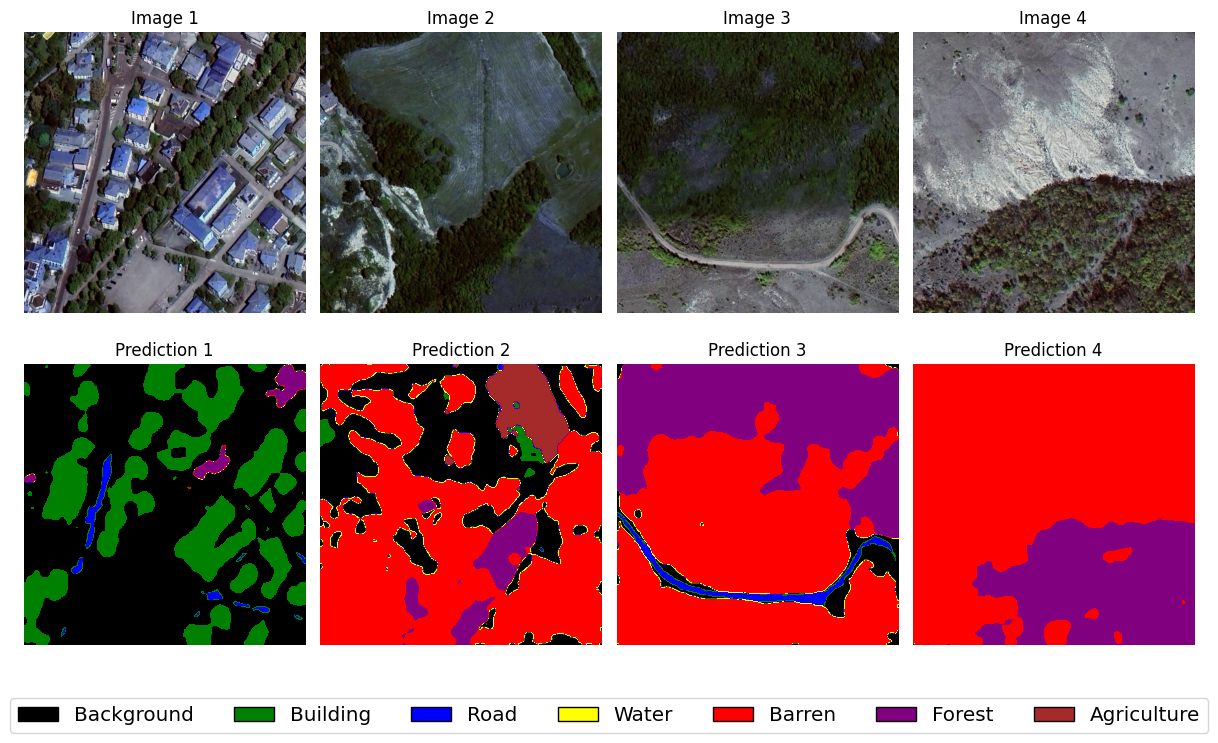

In [13]:
fig, axes = plt.subplots(2,4, figsize=(12,7))

cmap = ListedColormap(['black', 'green', 'blue', 'yellow', 'red', 'purple', 'brown'])
class_names = ['Background', 'Building', 'Road', 'Water', 'Barren', 'Forest', 'Agriculture']

for i in range(BATCH_SIZE):
    axes[0, i].imshow(reverse_preprocess_input(batch_images[0][i]))
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Image {i+1}')

    axes[1, i].imshow(np.argmax(predictions[i], axis=-1), cmap=cmap, norm=BoundaryNorm(range(8), cmap.N))
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Prediction {i+1}')

legend_elements = [
    mpatches.Patch(facecolor='black', edgecolor='black', linewidth=1, label='Background'),
    mpatches.Patch(facecolor='green', edgecolor='black', linewidth=1, label='Building'),
    mpatches.Patch(facecolor='blue', edgecolor='black', linewidth=1, label='Road'),
    mpatches.Patch(facecolor='yellow', edgecolor='black', linewidth=1, label='Water'),
    mpatches.Patch(facecolor='red', edgecolor='black', linewidth=1, label='Barren'),
    mpatches.Patch(facecolor='purple', edgecolor='black', linewidth=1, label='Forest'),
    mpatches.Patch(facecolor='brown', edgecolor='black', linewidth=1, label='Agriculture')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=7, fontsize='x-large')

fig.tight_layout()
plt.show()

##### Image for the thesis PDF.

In [9]:
# Batch 77
batch_77 = oos_dataloader.__getitem__(77)
predictions_77 = deeplab.predict(batch_77)

# Batch 17
batch_17 = oos_dataloader.__getitem__(17)
predictions_17 = deeplab.predict(batch_17)

# Batch 2
batch_2 = oos_dataloader.__getitem__(2)
predictions_2 = deeplab.predict(batch_2)

# Image 229
image_207 = Image.open('Images/229.tif')
numpy_image = np.array(image_207)

numpy_image = tf.image.resize(numpy_image, (512, 512))
numpy_image = tf.keras.applications.resnet.preprocess_input(numpy_image)
numpy_image = tf.expand_dims(numpy_image, axis=0)

prediction207 = deeplab.predict(numpy_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


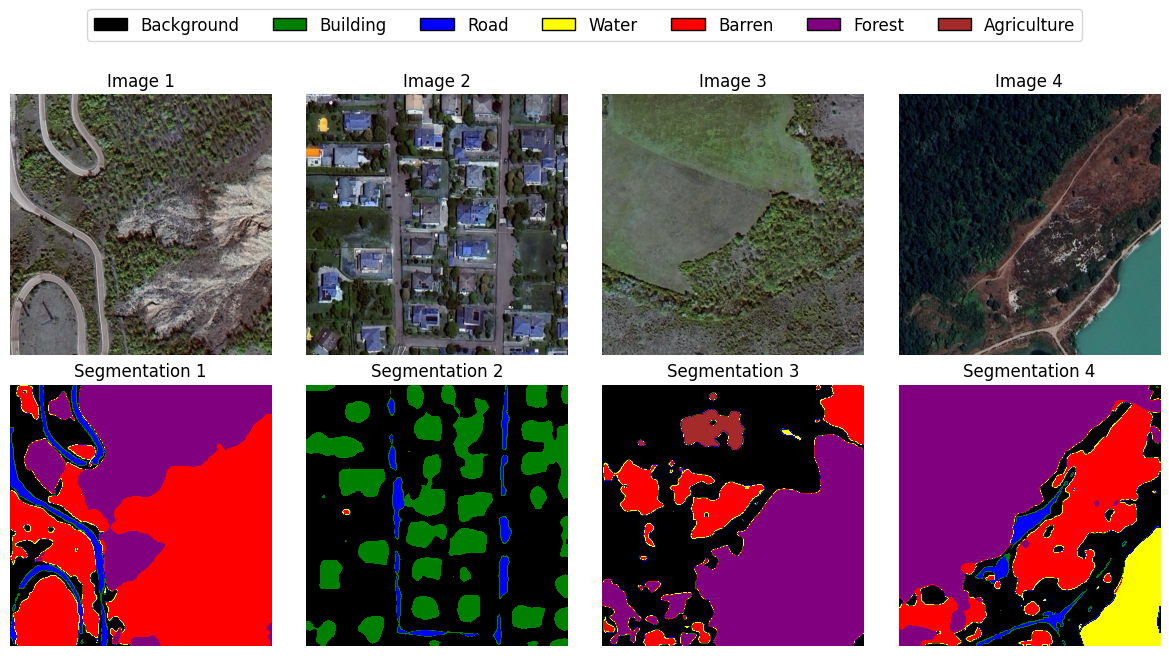

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

cmap = ListedColormap(['black', 'green', 'blue', 'yellow', 'red', 'purple', 'brown'])
class_names = ['Background', 'Building', 'Road', 'Water', 'Barren', 'Forest', 'Agriculture']

# Image 1 in batch 77
axes[0,0].imshow(reverse_preprocess_input(batch_77[0][0]))
axes[0,0].set_title('Image 1')
axes[0,0].axis('off')

axes[1,0].imshow(np.argmax(predictions_77[0], axis=-1), cmap=cmap, norm=BoundaryNorm(range(8), cmap.N))
axes[1,0].set_title('Segmentation 1')
axes[1,0].axis('off')

# Image 4 in batch 17
axes[0,1].imshow(reverse_preprocess_input(batch_17[0][3]))
axes[0,1].set_title('Image 2')
axes[0,1].axis('off')

axes[1,1].imshow(np.argmax(predictions_17[3], axis=-1), cmap=cmap, norm=BoundaryNorm(range(8), cmap.N))
axes[1,1].set_title('Segmentation 2')
axes[1,1].axis('off')

# Image 1 in batch 2
axes[0,2].imshow(reverse_preprocess_input(batch_2[0][0]))
axes[0,2].set_title('Image 3')
axes[0,2].axis('off')

axes[1,2].imshow(np.argmax(predictions_2[0], axis=-1), cmap=cmap, norm=BoundaryNorm(range(8), cmap.N))
axes[1,2].set_title('Segmentation 3')
axes[1,2].axis('off')

# Image 229
axes[0,3].imshow(image_207)
axes[0,3].set_title('Image 4')
axes[0,3].axis('off')

axes[1,3].imshow(np.argmax(prediction207[0], axis=-1), cmap=cmap, norm=BoundaryNorm(range(8), cmap.N))
axes[1,3].set_title('Segmentation 4')
axes[1,3].axis('off')



legend_elements = [
    mpatches.Patch(facecolor='black', edgecolor='black', linewidth=1, label='Background'),
    mpatches.Patch(facecolor='green', edgecolor='black', linewidth=1, label='Building'),
    mpatches.Patch(facecolor='blue', edgecolor='black', linewidth=1, label='Road'),
    mpatches.Patch(facecolor='yellow', edgecolor='black', linewidth=1, label='Water'),
    mpatches.Patch(facecolor='red', edgecolor='black', linewidth=1, label='Barren'),
    mpatches.Patch(facecolor='purple', edgecolor='black', linewidth=1, label='Forest'),
    mpatches.Patch(facecolor='brown', edgecolor='black', linewidth=1, label='Agriculture')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=7, fontsize='large')

fig.tight_layout()
plt.show()